In [6]:
# %pip install optuna

In [7]:
from pathlib import Path
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# import necessary functions/models from sklearn
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error , mean_absolute_error 
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor

# import xgboost regressor from xgboost
from xgboost import XGBRegressor

# import hyperparameter tuners from optuna
import optuna
from optuna import create_study
from optuna.samplers import TPESampler  # Bayesian/TPE sampler


from src.data_utils.preprocessing import (
    PreprocessingConfig,
    prepare_train_test_split,
    get_correlated_features,
    plot_hist_grid
)

config = PreprocessingConfig(
    # adjust if your column names differ
    date_col="Date",
    store_col="Store",
    target_col="Sales",
    lags=(1, 7, 14, 28, 365),
)

> 📦 **Data Prep:** Load train/test sets plus the fitted X and y scalers via the preprocessing module here.

In [8]:
train, test, x_scaler, y_scaler = prepare_train_test_split(
    train_path=Path("data/train.csv"),
    store_path=Path("data/store.csv"),
    config=config
)

c:\Users\18vic\OneDrive\Desktop\df_final\CAP_3764_2025_Fall_Team_2\src\data_utils\preprocessing.py:78: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(Path(path))


> **Save Artifacts:** Persist the fitted scalers now so they can be reused later.

In [9]:
joblib.dump(x_scaler, Path("artifacts/x_scaler.joblib"))
joblib.dump(y_scaler, Path("artifacts/y_scaler.joblib"))

['artifacts\\y_scaler.joblib']

>  **Data Check:** Inspect the train dataset here to confirm everything looks correct.

In [10]:
train.describe()

,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceYear,Promo2,...,sqrt_Sales_lag1,sqrt_Customers_lag1,sqrt_Sales_lag7,sqrt_Customers_lag7,sqrt_Sales_lag14,sqrt_Customers_lag14,sqrt_Sales_lag28,sqrt_Customers_lag28,sqrt_Sales_lag365,sqrt_Customers_lag365
count,758389.000000,7.583890e+05,7.583890e+05,758389.000000,758389.000000,758389.000000,758389.000000,7.564310e+05,758389.000000,758389.000000,...,7.572740e+05,7.572740e+05,7.505840e+05,7.505840e+05,7.427790e+05,7.427790e+05,7.271690e+05,7.271690e+05,3.514140e+05,3.514140e+05
mean,4.003701,-7.435323e-17,-1.577008e-16,0.831360,0.380583,0.028285,0.182874,1.521724e-17,1369.726969,0.498644,...,-4.623894e-17,9.175727e-16,-2.447666e-16,7.894330e-16,6.356419e-16,-3.162138e-16,1.238226e-16,2.234123e-16,-1.203467e-16,-2.199885e-16
std,1.998456,1.000001e+00,1.000001e+00,0.374434,0.485531,0.165786,0.386564,1.000001e+00,935.881626,0.499998,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,1.000000,-1.499204e+00,-1.363769e+00,0.000000,0.000000,0.000000,0.000000,-7.009207e-01,-1.000000,0.000000,...,-1.972289e+00,-1.931916e+00,-1.965717e+00,-1.925209e+00,-1.965383e+00,-1.924717e+00,-1.962899e+00,-1.922737e+00,-1.986744e+00,-1.942488e+00
25%,2.000000,-5.322138e-01,-4.970486e-01,1.000000,0.000000,0.000000,0.000000,-6.115947e-01,-1.000000,0.000000,...,-1.947954e-01,-1.964736e-01,-1.935817e-01,-1.961936e-01,-1.931122e-01,-1.948454e-01,-1.941218e-01,-1.966056e-01,-1.984443e-01,-2.072234e-01
50%,4.000000,-1.067914e-02,-5.401056e-02,1.000000,0.000000,0.000000,0.000000,-4.018729e-01,2006.000000,0.000000,...,2.308390e-01,2.005613e-01,2.331382e-01,2.029030e-01,2.331180e-01,2.027001e-01,2.325860e-01,2.027255e-01,2.298558e-01,1.986486e-01
75%,6.000000,5.389260e-01,4.384929e-01,1.000000,1.000000,0.000000,0.000000,1.884551e-01,2011.000000,1.000000,...,6.051031e-01,5.690079e-01,6.060565e-01,5.696647e-01,6.055633e-01,5.684082e-01,6.059292e-01,5.695886e-01,6.055980e-01,5.676551e-01
max,7.000000,8.479474e+00,1.452538e+01,1.000000,1.000000,1.000000,1.000000,9.117167e+00,2015.000000,1.000000,...,3.729946e+00,5.489434e+00,3.733998e+00,5.487028e+00,3.740980e+00,5.491191e+00,3.737654e+00,5.486356e+00,3.662666e+00,5.515115e+00


In [11]:
print(sorted(train.columns))

['Assortment', 'CompetitionDistance', 'CompetitionOpenSinceYear', 'Competition_open_since_August', 'Competition_open_since_December', 'Competition_open_since_February', 'Competition_open_since_January', 'Competition_open_since_July', 'Competition_open_since_June', 'Competition_open_since_March', 'Competition_open_since_May', 'Competition_open_since_November', 'Competition_open_since_October', 'Competition_open_since_September', 'Customers', 'Customers_lag1', 'Customers_lag14', 'Customers_lag28', 'Customers_lag365', 'Customers_lag7', 'Day', 'DayOfWeek', 'Month', 'Open', 'Promo', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Promo2_Interval_in_Aug', 'Promo2_Interval_in_Dec', 'Promo2_Interval_in_Feb', 'Promo2_Interval_in_Jan', 'Promo2_Interval_in_Jul', 'Promo2_Interval_in_Jun', 'Promo2_Interval_in_Mar', 'Promo2_Interval_in_May', 'Promo2_Interval_in_Nov', 'Promo2_Interval_in_Oct', 'Promo2_Interval_in_Sept', 'Sales', 'Sales_lag1', 'Sales_lag14', 'Sales_lag28', 'Sales_lag365', 'Sales_lag7

In [38]:
train = train[train['Open'] == 1].copy()
train.drop(columns=['Open'], inplace=True)

In [35]:
cols_not_to_use = ['Store', 'Customers', 'Sales', 'Open']

In [36]:
def format_correlated(features, title="Correlated Features"):
    if not features:
        return f"{title}:\n  (none)\n"
    bullet = "\n".join(f"  • {name}" for name in features)
    return f"{title} ({len(features)}):\n{bullet}\n"

In [37]:
#num_feats = train.select_dtypes(include = 'float64').columns
corr_cols, corr_df = get_correlated_features(train[[c for c in train.columns if c not in cols_not_to_use]], target_col= 'sqrt_Sales', threshold=config.corr_threshold)
print(format_correlated(corr_cols, title="High-correlation columns with target feature"))

High-correlation columns with target feature (16):
  • Sales_lag1
  • Customers_lag1
  • Sales_lag7
  • Customers_lag7
  • Sales_lag14
  • Customers_lag14
  • Sales_lag28
  • Customers_lag28
  • Sales_lag365
  • Customers_lag365
  • sqrt_Sales_lag7
  • sqrt_Customers_lag7
  • sqrt_Sales_lag14
  • sqrt_Customers_lag14
  • sqrt_Sales_lag28
  • sqrt_Customers_lag28



In [39]:
corr_df

,Feature,Correlation
0,sqrt_Sales_lag28,0.803183
1,sqrt_Customers_lag28,0.789340
2,sqrt_Sales_lag14,0.780225
3,sqrt_Customers_lag14,0.763683
4,sqrt_Customers_lag7,0.760129
5,sqrt_Sales_lag7,0.757671
6,Sales_lag28,0.741778
7,Sales_lag14,0.727696
8,Customers_lag28,0.691349
9,Sales_lag7,0.682287


In [40]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 292551 entries, 2014-01-01 to 2014-12-07
Data columns (total 48 columns):
 #   Column                            Non-Null Count   Dtype   
---  ------                            --------------   -----   
 0   DayOfWeek                         292551 non-null  int64   
 1   Promo                             292551 non-null  int64   
 2   StateHoliday                      292551 non-null  int64   
 3   SchoolHoliday                     292551 non-null  int64   
 4   CompetitionOpenSinceYear          292551 non-null  int64   
 5   Promo2                            292551 non-null  int64   
 6   Promo2SinceWeek                   292551 non-null  int64   
 7   Promo2SinceYear                   292551 non-null  int64   
 8   Competition_open_since_August     292551 non-null  int64   
 9   Competition_open_since_December   292551 non-null  int64   
 10  Competition_open_since_February   292551 non-null  int64   
 11  Competition_open_since_

In [41]:
selected_columns = train.select_dtypes(include = 'int64').columns.tolist() + ['Store'] + corr_cols + ['sqrt_Sales']

In [42]:
train = train[selected_columns]
test = test[selected_columns]

> ❌ **Warning:** The following block is compute-intensive and may take a while. It fits an unoptimized RandomForest on the full training set to extract feature importances for feature selection.

In [43]:
rs = 42

# define features properly
drop_cols = ['Store', 'Sales', 'sqrt_Sales', 'Date']
feature_cols = [c for c in train.columns if c not in drop_cols]

# train RF
rf = RandomForestRegressor(
    random_state=rs,
    verbose=1,
    n_jobs=-1,
    n_estimators=400  # more stable ranking
)

rf.fit(train[feature_cols], train['sqrt_Sales'])

# print importances sorted
importances = rf.feature_importances_
for name, imp in sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)[:25]:
    print(f"{name}: {imp:.4f}")


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   59.8s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  5.7min
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed: 12.4min finished


Sales_lag14: 0.2670
sqrt_Sales_lag14: 0.2508
Sales_lag1: 0.0968
Sales_lag28: 0.0878
sqrt_Sales_lag28: 0.0808
Promo: 0.0601
Sales_lag7: 0.0328
sqrt_Sales_lag7: 0.0316
DayOfWeek: 0.0209
Sales_lag365: 0.0135
Customers_lag1: 0.0084
Customers_lag7: 0.0065
sqrt_Customers_lag7: 0.0065
Customers_lag365: 0.0046
Customers_lag28: 0.0042
sqrt_Customers_lag28: 0.0041
sqrt_Customers_lag14: 0.0036
Customers_lag14: 0.0036
CompetitionOpenSinceYear: 0.0034
Promo2SinceWeek: 0.0022
Promo2SinceYear: 0.0018
SchoolHoliday: 0.0013
StateHoliday: 0.0009
Competition_open_since_September: 0.0006
Competition_open_since_March: 0.0005


> 🌟 **Feature Spotlight:** Let's reveal the most important features according to the Random Forest.

In [45]:
imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
})

imp_df = imp_df.sort_values("importance", ascending=False)
imp_df['cum_importance'] = imp_df['importance'].cumsum()

selected = imp_df.loc[imp_df["cum_importance"] <= 0.975, "feature"].tolist()

print("Selected Features:")
print(selected)

Selected Features:
['Sales_lag14', 'sqrt_Sales_lag14', 'Sales_lag1', 'Sales_lag28', 'sqrt_Sales_lag28', 'Promo', 'Sales_lag7', 'sqrt_Sales_lag7', 'DayOfWeek', 'Sales_lag365', 'Customers_lag1', 'Customers_lag7', 'sqrt_Customers_lag7', 'Customers_lag365', 'Customers_lag28']


In [21]:
tscv = TimeSeriesSplit(n_splits= 5)

# Just to make sure the tiem series split is working
for i, (train_idx, test_idx) in enumerate(tscv.split(train), 1):
    print(f"Split {i}:")
    print(f"train rows={len(train_idx)}, test rows={len(test_idx)}")
    print(f"Train Min date: {train.iloc[train_idx].index.min()} , Train Max date: {train.iloc[train_idx].index.max()}")
    print(f"Test Min date: {train.iloc[test_idx].index.min()} , Test Max date: {train.iloc[test_idx].index.max()}")
    print("="*70)


Split 1:
train rows=126399, test rows=126398
Train Min date: 2013-01-01 00:00:00 , Train Max date: 2013-04-24 00:00:00
Test Min date: 2013-04-24 00:00:00 , Test Max date: 2013-08-15 00:00:00
Split 2:
train rows=252797, test rows=126398
Train Min date: 2013-01-01 00:00:00 , Train Max date: 2013-08-15 00:00:00
Test Min date: 2013-08-15 00:00:00 , Test Max date: 2013-12-07 00:00:00
Split 3:
train rows=379195, test rows=126398
Train Min date: 2013-01-01 00:00:00 , Train Max date: 2013-12-07 00:00:00
Test Min date: 2013-12-07 00:00:00 , Test Max date: 2014-03-30 00:00:00
Split 4:
train rows=505593, test rows=126398
Train Min date: 2013-01-01 00:00:00 , Train Max date: 2014-03-30 00:00:00
Test Min date: 2014-03-30 00:00:00 , Test Max date: 2014-07-25 00:00:00
Split 5:
train rows=631991, test rows=126398
Train Min date: 2013-01-01 00:00:00 , Train Max date: 2014-07-25 00:00:00
Test Min date: 2014-07-25 00:00:00 , Test Max date: 2014-12-07 00:00:00


> 🧭 **Feature Set Build:** Create the train and test datasets here using the most important features for model training.

In [22]:
rmse = make_scorer(mean_squared_error)

# drop na rows in the datasets (they are present due to the lagged features)
train = train.dropna()
test = test.dropna()

X_train = train[selected]
y_train = train['sqrt_Sales'].values.ravel()

X_test = test[selected]
y_test = test['sqrt_Sales'].values.ravel()

In [23]:
# objective function to train Elastic Net using time series cross validation and optuna hyperparameter tuning
def objective_elastic(trial):
    model = ElasticNet(
        alpha=trial.suggest_float("alpha", 1e-4, 1e2, log=True),
        l1_ratio=trial.suggest_float("l1_ratio", 0.0, 1.0),
        max_iter=5000,
        random_state=rs,
    )
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring=rmse)
    return scores.mean()

In [24]:
# objective function to train Random Forest using time series cross validation and optuna hyperparameter tuning
def objective_rf(trial):
    model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        max_depth=trial.suggest_int("max_depth", 4, 20),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        n_jobs=-1,
        random_state=rs,
        verbose=0,
    )
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring=rmse)
    return scores.mean()

In [25]:
# objective function to train XGBoost using time series cross validation and optuna hyperparameter tuning
def objective_xgb(trial):
    model = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-6, 5.0, log=True),
        min_child_weight=trial.suggest_float("min_child_weight", 1e-3, 5.0, log=True),
        tree_method="hist",
        random_state=rs,
    )
    scores = cross_val_score(model, X_train, y_train,  cv=tscv, scoring=rmse)
    return scores.mean()

In [26]:
# function to define "study" or optimization process
def run_study(name, objective, n_trials=30):
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=42),
        study_name=name,
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print(f"{name} best RMSE: {study.best_value:.4f}")
    print(f"{name} best params: {study.best_params}")
    return study

>🚦 **Model Tuning:** The next blocks run cross-validation and hyperparameter optimization on the train dataset for ElasticNet, Random Forest, and XGBoost.

In [ ]:
study_elastic = run_study("ElasticNet", objective_elastic)

[I 2025-11-30 18:48:31,617] A new study created in memory with name: ElasticNet


[I 2025-11-30 18:48:32,494] Trial 0 finished with value: 0.08589067333830686 and parameters: {'alpha': 0.017670169402947963, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: 0.08589067333830686.
[I 2025-11-30 18:48:32,870] Trial 1 finished with value: 1.0148697160569469 and parameters: {'alpha': 2.465832945854912, 'l1_ratio': 0.5986584841970366}. Best is trial 0 with value: 0.08589067333830686.
[I 2025-11-30 18:48:34,857] Trial 2 finished with value: 0.061061097710211634 and parameters: {'alpha': 0.0008632008168602544, 'l1_ratio': 0.15599452033620265}. Best is trial 2 with value: 0.061061097710211634.
[I 2025-11-30 18:48:36,406] Trial 3 finished with value: 0.0603462374806613 and parameters: {'alpha': 0.00022310108018679258, 'l1_ratio': 0.8661761457749352}. Best is trial 3 with value: 0.0603462374806613.
[I 2025-11-30 18:48:36,891] Trial 4 finished with value: 0.41630971692088437 and parameters: {'alpha': 0.4042872735027334, 'l1_ratio': 0.7080725777960455}. Best is trial 3 

ElasticNet best RMSE: 0.0602
ElasticNet best params: {'alpha': 0.00010486661955429236, 'l1_ratio': 0.3071362867591333}


In [28]:
study_rf = run_study("RandomForest", objective_rf)

[I 2025-11-30 18:49:06,540] A new study created in memory with name: RandomForest
[I 2025-11-30 18:52:50,330] Trial 0 finished with value: 0.03467995096925114 and parameters: {'n_estimators': 287, 'max_depth': 20, 'max_features': 0.8123957592679836, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.03467995096925114.
[I 2025-11-30 18:53:11,887] Trial 1 finished with value: 0.06106238662482828 and parameters: {'n_estimators': 178, 'max_depth': 6, 'max_features': 0.3406585285177396, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.03467995096925114.
[I 2025-11-30 18:54:50,718] Trial 2 finished with value: 0.04086294271688078 and parameters: {'n_estimators': 401, 'max_depth': 16, 'max_features': 0.3144091460070617, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.03467995096925114.
[I 2025-11-30 18:56:18,114] Trial 3 finished with value: 0.04666943622690004 and parameters: {'n_estimators': 517, 'max_depth': 7, 'max_features': 0.42727747704497043, 'min_samples_leaf': 1}. Best

RandomForest best RMSE: 0.0339
RandomForest best params: {'n_estimators': 483, 'max_depth': 14, 'max_features': 0.7791598311700577, 'min_samples_leaf': 4}


In [29]:
study_xgb = run_study("XGBRegressor", objective_xgb)

[I 2025-11-30 20:36:58,857] A new study created in memory with name: XGBRegressor


[I 2025-11-30 20:38:56,336] Trial 0 finished with value: 0.03773552981187427 and parameters: {'n_estimators': 425, 'max_depth': 10, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 8.629132190071855e-06, 'reg_lambda': 2.4496293433163567e-06, 'min_child_weight': 1.599409170128044}. Best is trial 0 with value: 0.03773552981187427.
[I 2025-11-30 20:41:09,625] Trial 1 finished with value: 0.033807778283275 and parameters: {'n_estimators': 561, 'max_depth': 8, 'learning_rate': 0.010636066512540286, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'reg_alpha': 1.879466824163847e-05, 'reg_lambda': 1.6521139617131478e-05, 'min_child_weight': 0.004768785415482609}. Best is trial 1 with value: 0.033807778283275.
[I 2025-11-30 20:41:57,356] Trial 2 finished with value: 0.03389762955122702 and parameters: {'n_estimators': 382, 'max_depth': 7, 'learning_rate': 0.03647316284911211, 'subsample': 0.71649

XGBRegressor best RMSE: 0.0320
XGBRegressor best params: {'n_estimators': 492, 'max_depth': 4, 'learning_rate': 0.07558289765736041, 'subsample': 0.7483606904757055, 'colsample_bytree': 0.8012364486139857, 'reg_alpha': 0.0005672604069950822, 'reg_lambda': 2.669370061459247e-05, 'min_child_weight': 0.0011808249673940243}


> ✅ **Post-Tuning Fit:** With cross-validation and hyperparameter optimization done, pull the best hyperparameters and fit the prototype model on the full train dataset.

In [30]:
best_elastic = ElasticNet(**study_elastic.best_params, max_iter=5000, random_state=42)
best_elastic.fit(X_train, y_train)

,alpha,0.00010486661955429236
,l1_ratio,0.3071362867591333
,fit_intercept,True
,precompute,False
,max_iter,5000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [31]:
best_rf = RandomForestRegressor(**study_rf.best_params, n_jobs=-1, random_state=42)
best_rf.fit(X_train, y_train)

,n_estimators,483
,criterion,'squared_error'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,0.7791598311700577
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
best_xgb = XGBRegressor(
    **study_xgb.best_params,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)
best_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8012364486139857
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


> 📊 **Model Evaluation:** Visualize predictions and error metrics for both train and test datasets here.

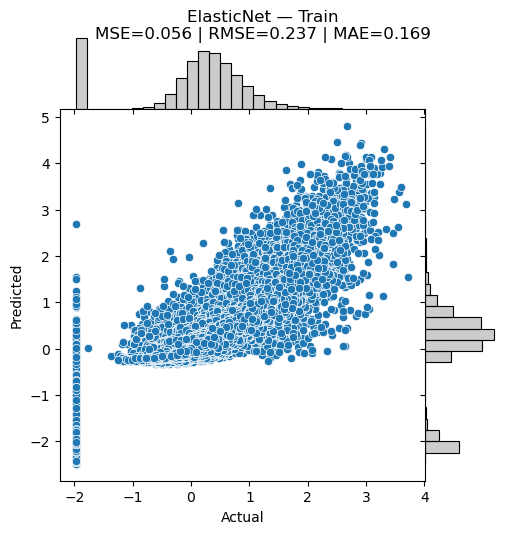

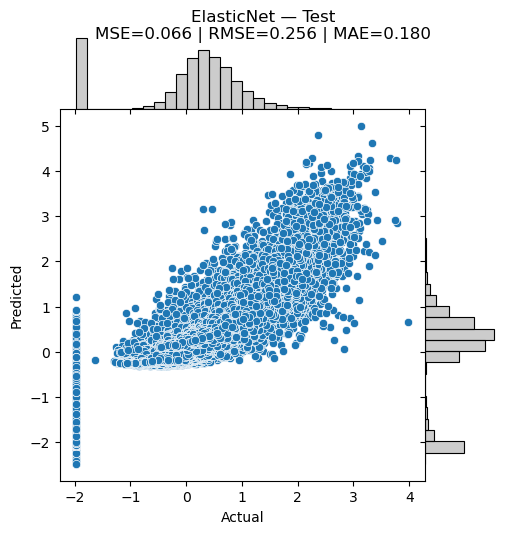

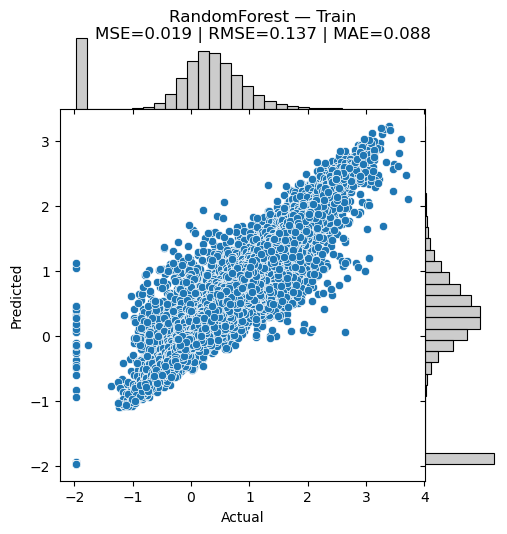

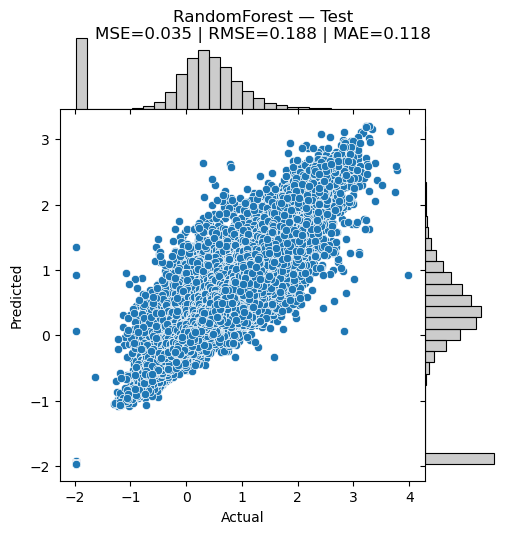

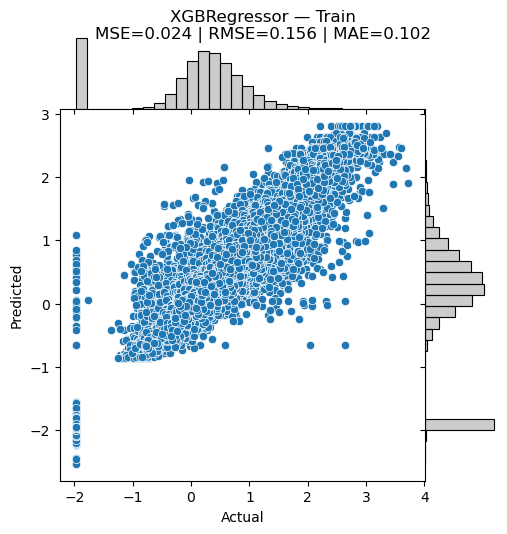

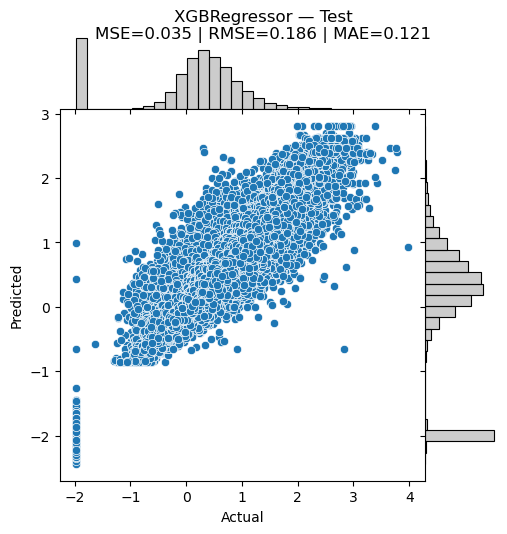

In [46]:
models = [
    ("ElasticNet", best_elastic),
    ("RandomForest", best_rf),
    ("XGBRegressor", best_xgb),
]

splits = [("Train", X_train, y_train), ("Test", X_test, y_test)]

for name, model in models:
    for split_name, X_split, y_split in splits:
        y_pred = model.predict(X_split)
        mse = mean_squared_error(y_split, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_split, y_pred)
        g = sns.jointplot(
            x=y_split,
            y=y_pred,
            kind="scatter",
            height=5,
            space=0,
            marginal_kws={"bins": 30, "fill": True, "color": "gray", "alpha": 0.4},
        )
        g.set_axis_labels("Actual", "Predicted")
        g.figure.suptitle(f"{name} — {split_name}\nMSE={mse:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}", y=1.02)

>  **Save Models:** Finally, save the trained models for future use.

In [34]:
joblib.dump(best_elastic, Path("models/prototype_elasticnet.joblib"))
joblib.dump(best_rf, Path("models/prototype_random_forest.joblib"))
joblib.dump(best_xgb, Path("models/prototype_xgb_regressor.joblib"))

['models\\prototype_xgb_regressor.joblib']

In [48]:
%pip install shap

   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 4.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 4.2 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.7 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 6.1 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.6/38.1 MB 8.4 MB/s eta 0:00:05
   --- ------------------------------------ 3.4/38.1 MB 8.8 MB/s eta 0:00:04
   ----- ---------------------------------- 5.0/38.1 MB 8.4 MB/s eta 0:00:04
   ------- -------------------------------- 6.8/38.1 MB 8.6 MB/s eta 0:00:04
   -------- ------------------------------- 8.4/38.1 MB 8.4 MB/s eta 0:00:04
   ---------- ----------------------------- 10.5/38.1 MB 8.5 MB/s eta 0:00:04
   ------------ ---------

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

def explain_model_with_shap(model, X_train, X_valid=None, top_n=10, sample_size=200):
    """
    Compute and visualize SHAP values for a trained tree-based model.
    
    Parameters:
        model: Trained model with predict() method (LightGBM, XGBoost, RF, etc.)
        X_train: Training features DataFrame
        X_valid: Validation features DataFrame (optional)
        top_n: Number of top features to show in dependence plots
        sample_size: Samples for force plot to avoid heavy computation
    """
    
    if X_valid is None:
        X_valid = X_train
    
    # Create SHAP explainer
    explainer = shap.Explainer(model.predict, X_train)
    shap_values = explainer(X_valid)
    
    # Ensure sample size does not exceed validation rows
    sample_size = min(sample_size, X_valid.shape[0])
    sample_idx = np.random.choice(X_valid.index, size=sample_size, replace=False)
    
    print("Generating SHAP Summary Plot...")
    shap.summary_plot(shap_values, X_valid, show=False)
    plt.title("SHAP Feature Impact Summary")
    plt.show()

    # Dependence plots for top_n features
    print(f"Generating top {top_n} SHAP dependence plots...")
    importances = np.abs(shap_values).mean(axis=0)
    top_features = X_valid.columns[np.argsort(importances)[-top_n:][::-1]]
    
    for feat in top_features:
        shap.dependence_plot(feat, shap_values, X_valid, show=False)
        plt.title(f"Dependence Plot: {feat}")
        plt.show()

    # Force plot for a single prediction
    print("Generating SHAP force plot for sample predictions...")
    for i in sample_idx[:3]:  # show 3 force plots max
        display(shap.force_plot(
            explainer.expected_value,
            shap_values[X_valid.index.get_loc(i)],
            X_valid.loc[i],
            matplotlib=True
        ))


=== SHAP for ElasticNet ===


PermutationExplainer explainer: 292552it [1:01:55, 78.74it/s]                             


Generating SHAP Summary Plot...


C:\Users\18vic\AppData\Local\Temp\ipykernel_17804\3982674805.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_valid, show=False)


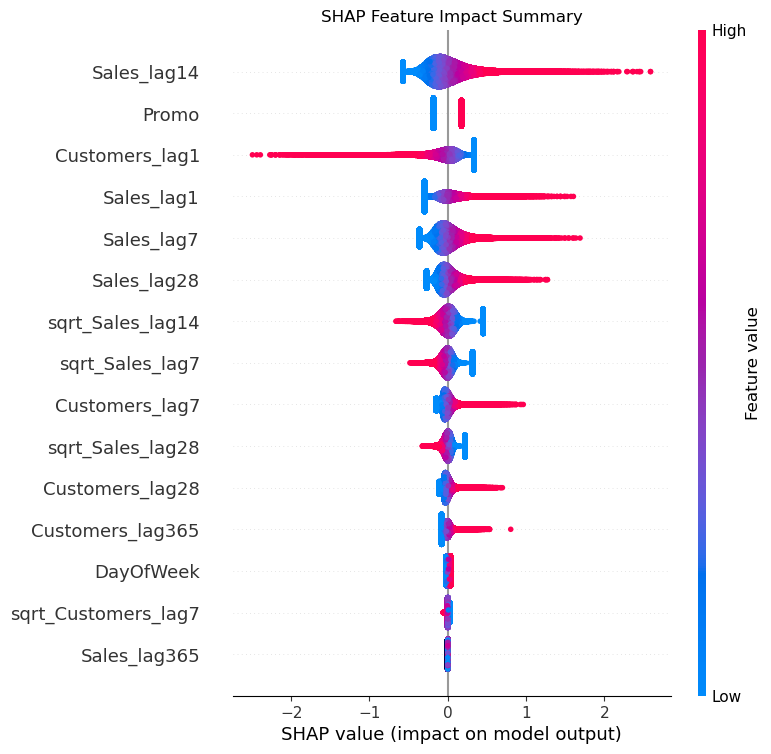

Generating top 10 SHAP dependence plots...


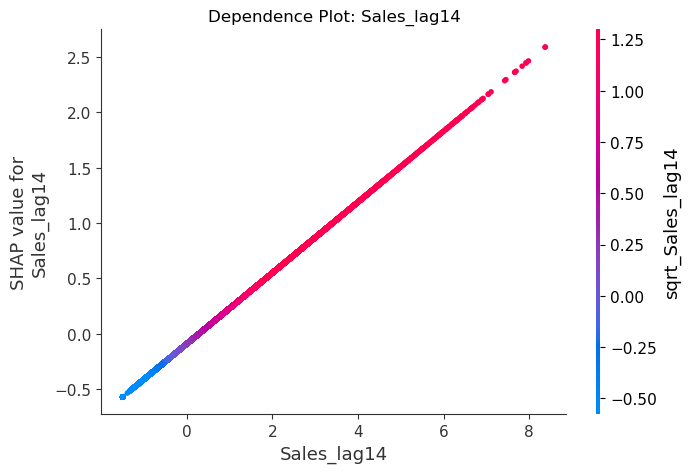

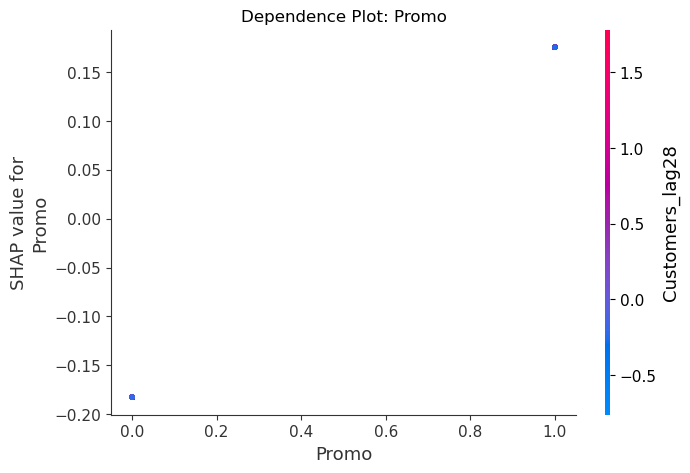

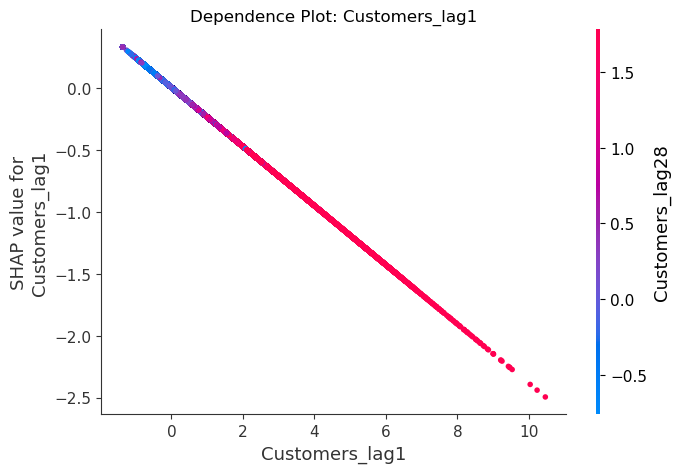

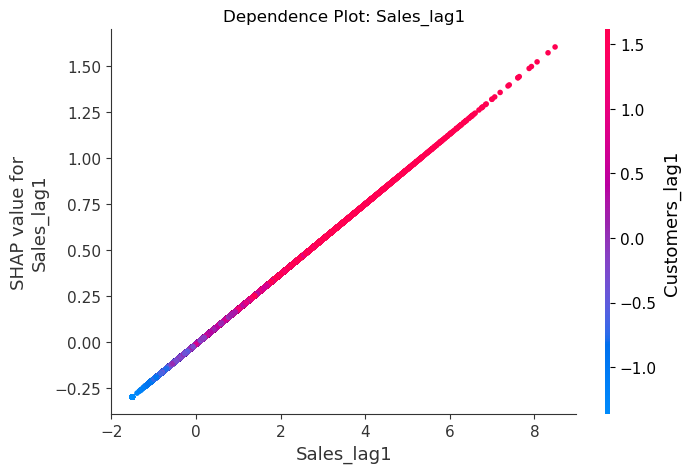

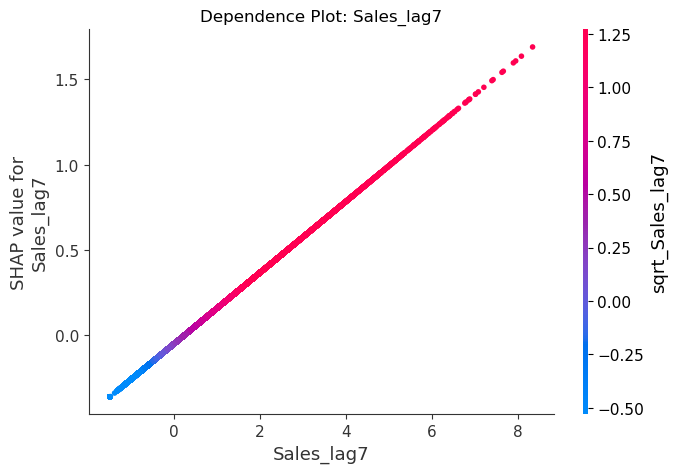

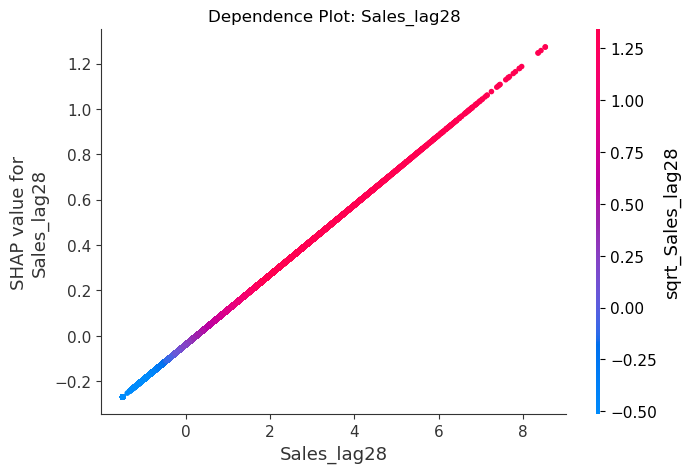

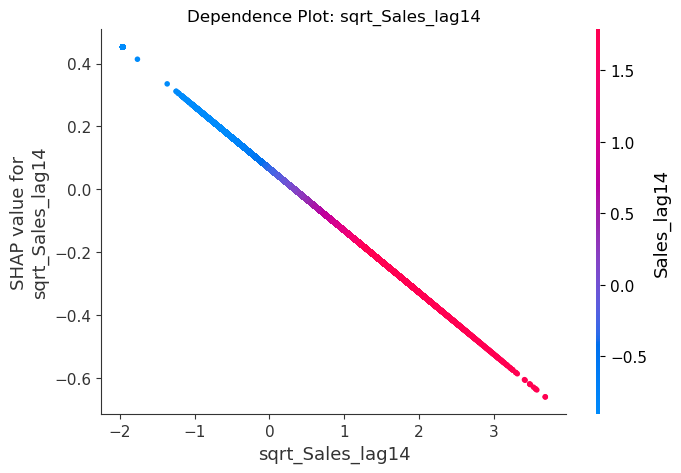

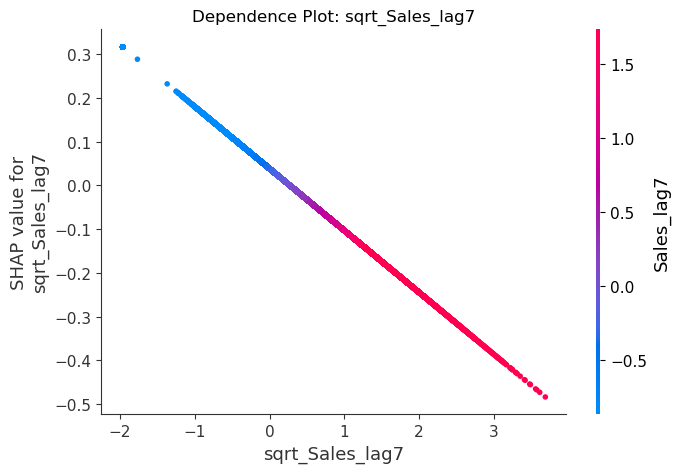

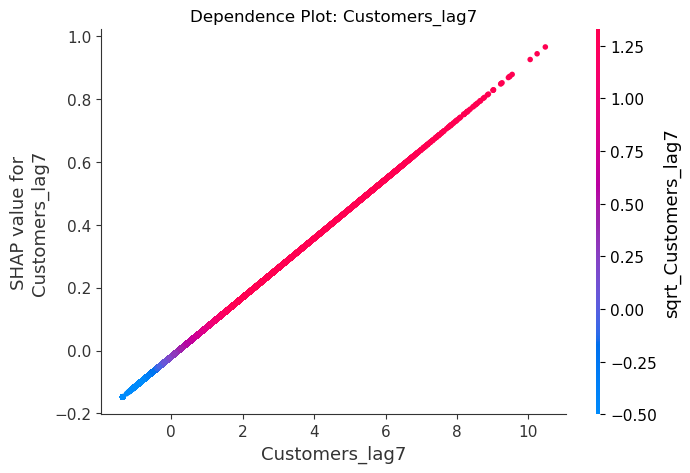

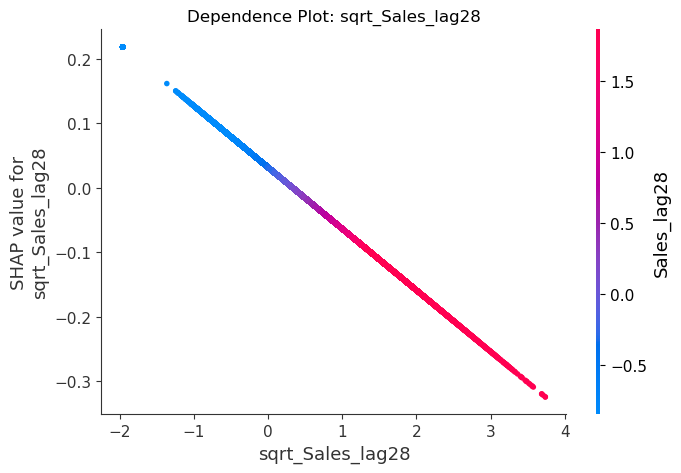

Generating SHAP force plot for sample predictions...


AttributeError: 'PermutationExplainer' object has no attribute 'expected_value'

In [ ]:
#  for reference already instantiated above
models = [
    ("ElasticNet", best_elastic),
    ("RandomForest", best_rf),
    ("XGBRegressor", best_xgb),
]

X = train[selected]
y = train['sqrt_Sales']

for name, model in models:
    print(f"=== SHAP for {name} ===")
    model.fit(X, y)
    explain_model_with_shap(model, X)
